## Ejercicio 5

El dataset MNIST consiste en un conjunto de 70,000 imágenes en escala de grises de dígitos escritos a mano (0 a 9), con un tamaño de 28x28 píxeles.

<div style="text-align: center;">
    <img src='../imagenes/p6-ej5.png' width="80%">
</div>


Desarrolle un autoencoder variacional para realizar una representación comprimida del dataset MNIST, utilizando TensorFlow/Keras. Use 2 dimensiones para codificar el espacio latente. Luego de entrenar el modelo:



In [1]:
FUENTES_DIR = '../FUENTES'         # carpeta donde se encuentran archivos .py auxiliares
DATOS_DIR   = '../Data_Sets/p6/' # carpeta donde se encuentran los datasets
LOCAL_DIR = DATOS_DIR 

import os
MODELOS_DIR = os.path.abspath(DATOS_DIR+'Modelos/')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# agrega ruta de busqueda donde tenemos archivos .py
import sys
sys.path.append(FUENTES_DIR)

# Cargar imagenes

In [2]:
from tensorflow import keras
import numpy as np

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = np.expand_dims(x_train, -1).astype("float32") / 255
x_test = np.expand_dims(x_test, -1).astype("float32") / 255

## Define el codificador

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from ipywidgets import interact
from matplotlib import pyplot as plt

# espacio de dimensiones latentes
latent_dim = 3

encoder_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var], name="encoder")
encoder.summary()

E0000 00:00:1761932506.402834   56277 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1761932506.410144   56277 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 14, 14,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │     50,192 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 3)         │         51 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 3)         │         51 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,110 (269.96 KB)

 Trainable params: 69,110 (269.96 KB)

 Non-trainable params: 0 (0.00 B)

## Define funcion de muestreo

In [4]:
class Sampler(layers.Layer):
    def call(self, z_mean, z_log_var):
        batch_size, z_size = tf.shape(z_mean)[0], tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch_size, z_size))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

## Define el bloque decodificador

In [5]:
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3136)           │        12,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,225 (266.50 KB)

 Trainable params: 68,225 (266.50 KB)

 Non-trainable params: 0 (0.00 B)

## Define el paso de entrenamiento y las metricas utilizando una clase

In [6]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.sampler = Sampler()
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")


    @property
    def metrics(self):
        return [self.total_loss_tracker,
                self.reconstruction_loss_tracker,
                self.kl_loss_tracker]


    def train_step(self, data):

        with tf.GradientTape() as tape: # GradientTape para registrar las operaciones para la diferenciación automática

            z_mean, z_log_var = self.encoder(data) # Codifica entrada y obtiene media y log-varianza del espacio latente

            z = self.sampler(z_mean, z_log_var)    # Muestrea del espacio latente usando reparametrización

            reconstruction = decoder(z)            # Reconstruye la entrada usando el decoder

            # Calcula la pérdida de reconstrucción (binary crossentropy)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2)
                )
            )

            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)) # Calcula Kullback-Leibler divergence
            kl_loss = tf.reduce_mean(kl_loss)
            total_loss = reconstruction_loss + kl_loss # Combina y obtiene pérdida total

        grads = tape.gradient(total_loss, self.trainable_weights)  # Calcula los gradientes

        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))  # Aplica gradientes para actualizar los pesos

        # Actualiza las métricas de pérdida
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        # Retorna diccionario con los valores de las métricas
        return {
            "total_loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

## Entrenar el modelo con MNIST

In [10]:
vae_model = VAE(encoder, decoder)
vae_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.005))
vae_model.fit(x_train, epochs=30, batch_size=256)

Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 29s 116ms/step - kl_loss: 1.5135 - reconstruction_loss: 213.3016 - total_loss: 214.8150
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 109ms/step - kl_loss: 2.2628 - reconstruction_loss: 186.5626 - total_loss: 188.8253
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 109ms/step - kl_loss: 3.1250 - reconstruction_loss: 161.5394 - total_loss: 164.6644
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 110ms/step - kl_loss: 3.5615 - reconstruction_loss: 144.6919 - total_loss: 148.2534
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 111ms/step - kl_loss: 3.6190 - reconstruction_loss: 139.1281 - total_loss: 142.7471
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 114ms/step - kl_loss: 3.6249 - reconstruction_loss: 136.2842 - total_loss: 139.9090
Epoch 7/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 111ms/step - kl_loss: 3.6211 - reconstruction_loss: 134.6737 - total_loss: 138.2948
Epoch 8/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 114ms/step - kl_loss: 3.6081 - reconstruction_loss: 133.6800

### Guarda codificador y decodificador para recrear el VAE sin entrenarlo

In [11]:
vae_model.encoder.save(MODELOS_DIR + 'VAE_MNIST_encoder_3d.keras')
vae_model.decoder.save(MODELOS_DIR + 'VAE_MNIST_decoder_3d.keras')

### Recupera codificador y decodificador para recrear el modelo VAE

In [9]:
encoder = keras.models.load_model(MODELOS_DIR + 'VAE_MNIST_encoder_3d.keras')
decoder = keras.models.load_model(MODELOS_DIR + 'VAE_MNIST_decoder_3d.keras')

vae_model = VAE(encoder, decoder)

## Muestra la grilla de imágenes generadas a partir del espacio latente


Generando gráficos


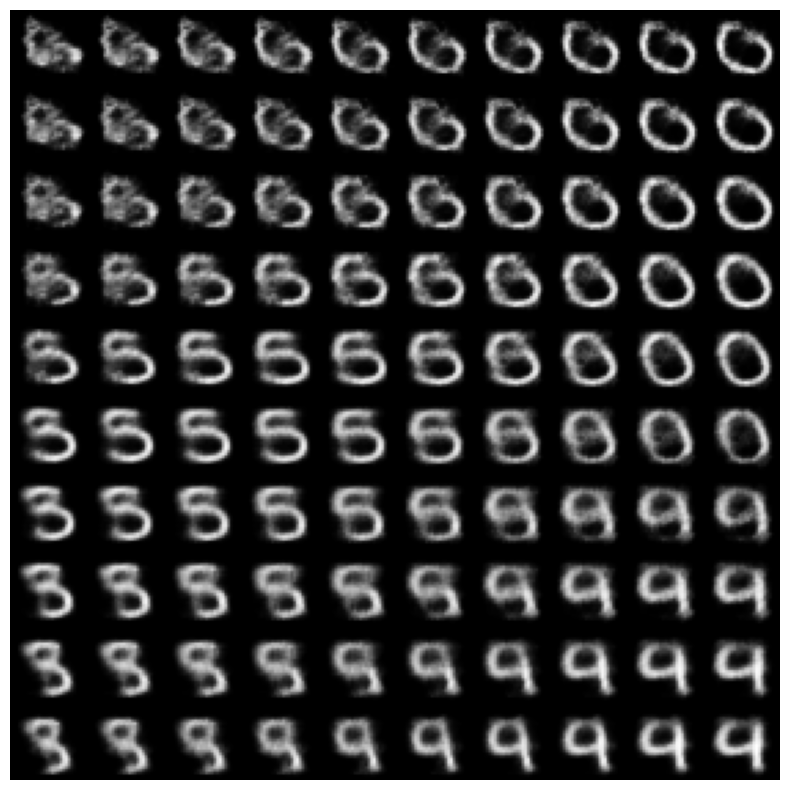

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def dibujar_espacio_latente(vae, n=30, latent_dim=2):
    digit_size = 28  # Tamaño de cada dígito
    scale = 1        # Escala para el espacio latente
    figure = np.zeros((digit_size * n, digit_size * n))  # matriz para almacenar las imágenes generadas

    # Puntos en el espacio latente a lo largo de los ejes X e Y
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]  # Invierte para una visualización más intuitiva

    # Iterar sobre los puntos en el espacio latente
    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = np.array([[xi, yi, 1]])  # Generar una muestra en el espacio latente
            x_decoded = vae.decoder.predict(z_sample, verbose=0)  # Decodificar la muestra para generar una imagen
            digit = x_decoded[0].squeeze()  # Eliminar la dimensión extra y obtener una matriz 2D
            # Reorganizar la imagen generada al tamaño del dígito y almacenarla en la matriz
            figure[
                i * digit_size : (i + 1) * digit_size,
                j * digit_size : (j + 1) * digit_size,
            ] = digit

    # Muestra matriz de imágenes generadas
    plt.figure(figsize=(10, 10))
    plt.imshow(figure, cmap=plt.cm.gray)  # Mostrar la matriz como una imagen
    plt.axis("off")  # Ocultar ejes y etiquetas
    plt.show()

print("Generando gráficos")
dibujar_espacio_latente(vae_model, n=10, latent_dim=3)

### a) 

Grafique en una cuadrícula las imágenes resultantes al variar las dimensiones de control del espacio latente.


In [ ]:
from ipywidgets import interact


def dibujar_digito_espacio_latente(vae, n=30, figsize=15):

    # Función para generar una imagen en función de coordenadas (xi, yi)
    def gen_img(xi, yi, zi):
        digit_size = 28

        z_sample = np.array([[xi, yi, zi]]) # Genera una muestra en el espacio latente

        # Decodificar la muestra para generar una imagen
        x_decoded = vae.decoder.predict(z_sample, verbose=0)

        return x_decoded[0]

    ESCALA = 100 # Escala barra de control

    # Función que muestra digito generado al interacturar con las barras
    def mostrar_imagen(x, y, z):
        # Invirtiendo 'y' para coincidir con la orientación gráfica
        plt.figure(figsize=(3,3))
        plt.imshow(gen_img(x/ESCALA, -y/ESCALA, -z/ESCALA), cmap=plt.cm.coolwarm, interpolation='nearest')
        plt.show()  # Mostrar la imagen generada
        plt.axis("off")  # Ocultar ejes y etiquetas

    interact(mostrar_imagen, x=(-ESCALA, ESCALA), y=(-ESCALA, ESCALA), z=(-ESCALA, ESCALA))

dibujar_digito_espacio_latente(vae_model)

### b) 

Utilizando 2 controles deslizantes para variar los parámetros, grafique una imagen reconstruida que se actualice automáticamente al mover cualquiera de los controles.

In [10]:
from ipywidgets import interact, FloatSlider
import matplotlib.pyplot as plt
import numpy as np

# Función para mostrar la imagen reconstruida a partir de los valores latentes
def mostrar_imagen_latente(z1, z2):
    z_sample = np.array([[z1, z2, 0]])  # Fijamos z3 = 0
    x_decoded = vae_model.decoder.predict(z_sample, verbose=0)
    digit = x_decoded[0].squeeze()

    plt.figure(figsize=(2, 2))
    plt.imshow(digit, cmap="gray")
    plt.axis("off")
    plt.show()

# Crear los sliders interactivos
interact(
    mostrar_imagen_latente,
    z1=FloatSlider(min=-3, max=3, step=0.1, value=0, description='z₁'),
    z2=FloatSlider(min=-3, max=3, step=0.1, value=0, description='z₂'),
);


interactive(children=(FloatSlider(value=0.0, description='z₁', max=3.0, min=-3.0), FloatSlider(value=0.0, desc…